# BTC-USD com Prophet: três anos versus 12 anos

Comparamos os dois CSVs locais com a mesma configuração do Prophet, usando `ds` como data e `y` como fechamento em USD por BTC. O histórico longo começa em 17/09/2014; o curto, em 05/10/2023. Ambos terminam em 04/10/2026.

| Etapa | Datas previstas | Regra |
| --- | --- | --- |
| Validação | 08/04/2026 a 06/07/2026 | Escolher a janela pelo menor MAE; empate favorece três anos |
| Teste final | 07/07/2026 a 04/10/2026 | Confrontar ambos e a referência simples nas mesmas 90 datas |

Cada avaliação prevê um bloco de 90 dias sem incorporar os preços observados dentro dele ao treinamento. As configurações são iguais, com semente 42 e `uncertainty_samples=0`. O teste permanece separado da seleção por validação.

A implementação canônica está em `training/train_compare.py`; este notebook chama o experimento uma vez e apresenta sua evidência. Os CSVs precisam estar disponíveis antes da execução. Fontes oficiais: [entrada e previsão no Prophet](https://facebook.github.io/prophet/docs/quick_start.html) e [avaliação temporal](https://facebook.github.io/prophet/docs/diagnostics.html).

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

root = Path.cwd()
if not (root / "data").is_dir():
    root = root.parent
sys.path.insert(0, str(root / "training"))
from train_compare import run_experiment

result = run_experiment(root)
print("Janela selecionada pela validação:", result["selection"]["selected_window"])

Importing plotly failed. Interactive plots will not work.


validacao: ajustando 3y, 916 registros até 2026-04-07


C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


15:21:47 - cmdstanpy - INFO - Chain [1] start processing


15:21:48 - cmdstanpy - INFO - Chain [1] done processing


...

15:21:51 - cmdstanpy - INFO - Chain [1] done processing


Teste 3y: MAE=16347.51 USD; RMSE=21582.53; sMAPE=25.06%


Teste 12y: MAE=28836.89 USD; RMSE=29900.36; sMAPE=33.77%


Referência simples: MAE=8707.09 USD


Janela selecionada pela validação: 3y


MAE é o erro absoluto médio, em USD, usado para selecionar a janela. RMSE também usa USD e dá maior peso a erros grandes. sMAPE expressa o erro relativo em porcentagem. Valores menores indicam menor erro neste recorte.

A primeira tabela mostra a seleção na validação. A segunda mostra o teste posterior, incluindo a referência simples implementada no script. Ela ajuda a conferir se o Prophet agrega valor em relação a uma previsão básica.

In [2]:
validation_rows = [
    {"modelo": window, "MAE (USD)": metrics["mae_usd"]}
    for window, metrics in result["validation"]["models"].items()
]
display(pd.DataFrame(validation_rows).set_index("modelo"))

test_rows = []
for window, metrics in result["test"]["models"].items():
    test_rows.append({
        "modelo": window,
        "MAE (USD)": metrics["mae_usd"],
        "RMSE (USD)": metrics["rmse_usd"],
        "sMAPE (%)": metrics["smape_percent"],
    })
baseline = result["test"]["baseline"]
test_rows.append({
    "modelo": "Referência simples",
    "MAE (USD)": baseline["mae_usd"],
    "RMSE (USD)": baseline["rmse_usd"],
    "sMAPE (%)": baseline["smape_percent"],
})
display(pd.DataFrame(test_rows).set_index("modelo"))

,MAE (USD)
modelo,
3y,16901.325795
12y,43627.856776


,MAE (USD),RMSE (USD),sMAPE (%)
modelo,,,
3y,16347.510002,21582.530130,25.060251
12y,28836.894628,29900.361685,33.771904
Referência simples,8707.092795,11875.248060,12.094752


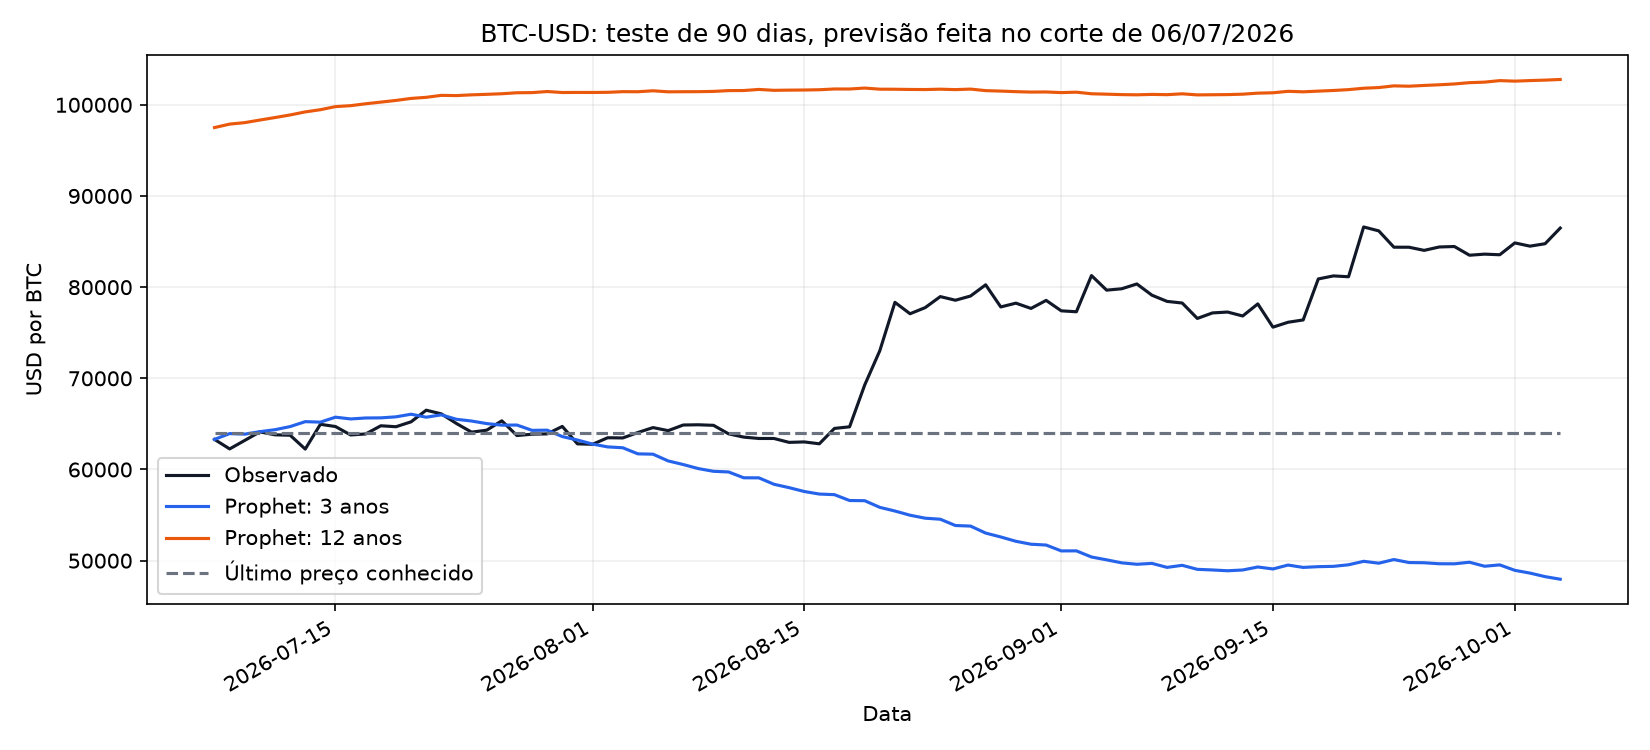

In [3]:
display(Image(filename=str(root / "reports" / "comparacao-teste.png")))

O gráfico confronta preços observados e previsões somente no teste final. Os resultados são medidos quando o notebook é executado; não há métricas preenchidas manualmente.

Depois da avaliação, o script reajusta a janela escolhida com os dados disponíveis até 04/10/2026 e exporta `models/modelo.json`. Esse artefato final usa dados adicionais e não possui avaliação independente posterior a essa data. Uma vitória neste único recorte não prova superioridade geral nem desempenho em outros horizontes.

Esta etapa cobre treinamento, comparação e exportação. A interface prevista continua no terminal, e a integração com backend e Docker pertence a uma próxima etapa.